In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV # used for hyper parameter tuning for svm model
from sklearn.model_selection import KFold
import scipy.io


In [ ]:
"""Sources/Background Research 
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
https://stackoverflow.com/questions/64839354/what-decision-tree-algorithms-is-used-for-random-forest-classifier-in-scikit-lea
https://scikit-learn.org/stable/modules/tree.html
https://stackoverflow.com/questions/7670280/tree-plotting-in-python
https://scikit-learn.org/stable/auto_examples/ensemble/plot_ensemble_oob.html
https://stackoverflow.com/questions/8409095/set-markers-for-individual-points-on-a-line
https://stackoverflow.com/questions/77718384/how-can-i-get-the-oob-score-of-each-tree-in-random-forestscikit-learn
https://scikit-learn.org/stable/modules/grid_search.html
https://stackoverflow.com/questions/57513586/how-to-use-grid-search-for-the-svm

"""

In [2]:

column_names = [f'feature_{i}' for i in range(57)] + ['label']  
df = pd.read_csv('data/spambase.data', header=None, names=column_names)
#adding this in since the problem stated that there are some missing values

df = df.fillna(0) 

# Display the first few rows
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,label
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


CART Test Error: 0.12812160694896846
Accuracy: 0.8718783930510315


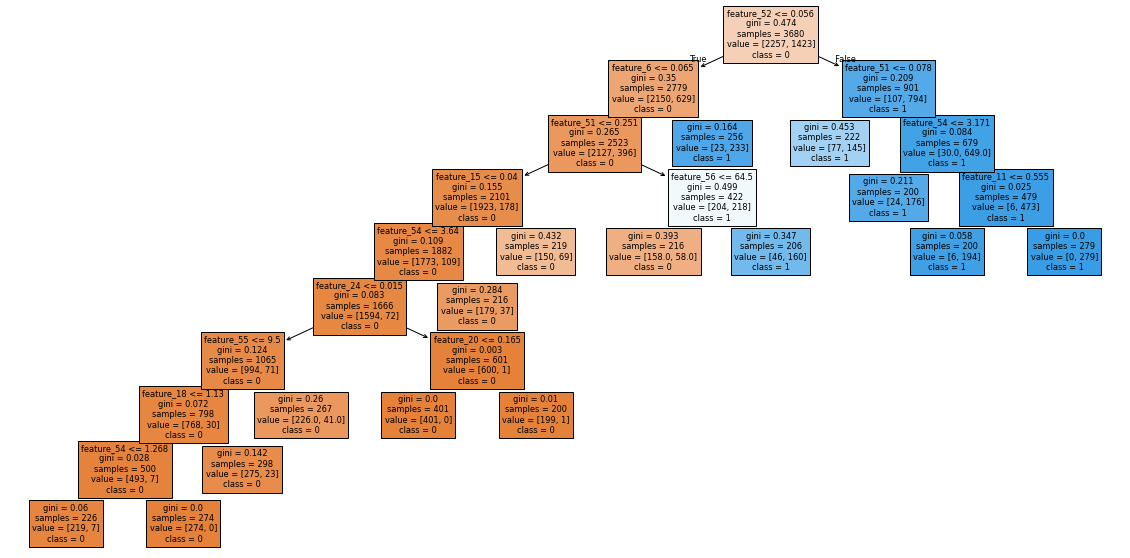

In [3]:


x = df.iloc[:, : 57]
y = df.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Create a CART model (DecisionTreeClassifier for classification, DecisionTreeRegressor for regression)
model = DecisionTreeClassifier(min_samples_leaf = 200)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
cart_pred = model.predict(X_test)

cart_error = 1 - accuracy_score(y_test, cart_pred)
print(f"CART Test Error: {cart_error}")

# Evaluate the model (e.g., accuracy for classification)
accuracy = accuracy_score(y_test, cart_pred)
print(f"Accuracy: {accuracy}")



#visualizing 
plt.figure(figsize=(20, 10)) 
plot_tree(model, filled=True, feature_names=x.columns.astype(str), class_names=['0', '1'])
plt.show()








## Random Forest Model



RF Test Error: 0.04777415852334421
CART Test Error: 0.12812160694896846


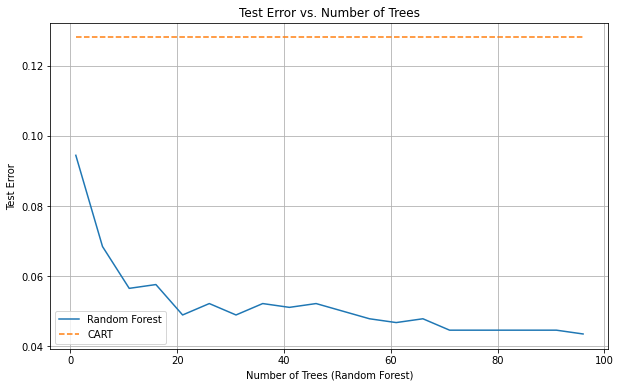

In [4]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

# Random Forest model
rf_errors = []
n_trees = range(1, 101, 5)  # Test with 1 to 100 trees, step by 5

for n in n_trees:
    rf_model = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_test)
    rf_error = 1 - accuracy_score(y_test, rf_pred)
    rf_errors.append(rf_error)

rf_error = 1 - accuracy_score(y_test, y_pred)
print(f"RF Test Error: {rf_error}")
print(f"CART Test Error: {cart_error}")
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(n_trees, rf_errors, label='Random Forest')
plt.plot(n_trees, [cart_error] * len(n_trees), label='CART', linestyle='--')  
plt.xlabel('Number of Trees (Random Forest)')
plt.ylabel('Test Error')
plt.title('Test Error vs. Number of Trees')
plt.legend()
plt.grid(True)
plt.show()

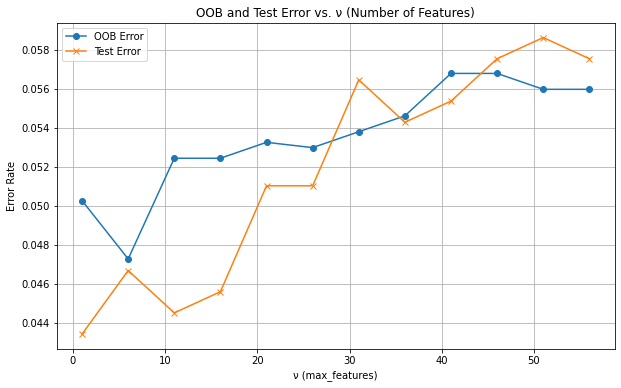

In [5]:
# Get total number of features
num_features = x.shape[1]

#stepping by 5 like before
nu_values = list(range(1, num_features + 1, 5))



oob_errors = []
test_errors = []

for nu in nu_values:
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_features=nu,
        oob_score=True,
        bootstrap=True,
        random_state=42
    )
    rf_model.fit(X_train, y_train)
    
    # Recording OOB error
    oob_error = 1 - rf_model.oob_score_
    oob_errors.append(oob_error)
    
    # Record Test error
    rf_pred = rf_model.predict(X_test)
    test_error = 1 - accuracy_score(y_test, rf_pred)
    test_errors.append(test_error)

# Plot both OOB and test error vs. ν
plt.figure(figsize=(10, 6))
plt.plot(nu_values, oob_errors, label='OOB Error', marker='o')
plt.plot(nu_values, test_errors, label='Test Error', marker='x')
plt.xlabel('ν (max_features)')
plt.ylabel('Error Rate')
plt.title('OOB and Test Error vs. ν (Number of Features)')
plt.legend()
plt.grid(True)
plt.show()


In [6]:
X_train_ocsvm, X_test_ocsvm, y_train_ocsvm, y_test_ocsvm = train_test_split(x, y, test_size=0.25, random_state=42, shuffle=True)

# Extract ONLY non-spam (label 0) from training set
X_train_nonspam = X_train_ocsvm[y_train_ocsvm == 0]

#train one class svm on non spam
ocsvm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.1)  # tune gamma and nu
ocsvm.fit(X_train_nonspam)

# predicton test
# Predict: +1 = inlier (non-spam), 
#-1 = outlier (spam)
y_pred_ocsvm = ocsvm.predict(X_test_ocsvm)

# Convert predictions 
y_pred_labels = (y_pred_ocsvm == -1).astype(int)  # -1 is spam, so becomes 1

# find misclassification error
misclass_error = 1 - accuracy_score(y_test_ocsvm, y_pred_labels)
print(f"One-Class SVM Misclassification Error: {misclass_error:.4f}")

One-Class SVM Misclassification Error: 0.3388


In [7]:

#Hyperparameter tuning to see which values of rgamma and nu perform the best
param_grid = {
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'nu': [0.01, 0.05, 0.1, 0.2, 0.3]
}

best_error = 1.0
best_params = {}

for gamma in param_grid['gamma']:
    for nu in param_grid['nu']:
        ocsvm = OneClassSVM(kernel='rbf', gamma=gamma, nu=nu)
        ocsvm.fit(X_train_nonspam)
        #checking which samples were predicted as spam
        preds = (ocsvm.predict(X_test_ocsvm) == -1).astype(int)
        error = 1 - accuracy_score(y_test_ocsvm, preds)
        if error < best_error:
            best_error = error
            best_params = {'gamma': gamma, 'nu': nu}

print(f"Best One-Class SVM Error: {best_error:.4f} using {best_params}")


Best One-Class SVM Error: 0.3032 using {'gamma': 0.001, 'nu': 0.01}
